In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! tar -xvf /content/drive/MyDrive/project_2/MSD/Task04_Hippocampus.tar

./._Task04_Hippocampus
Task04_Hippocampus/
Task04_Hippocampus/._.DS_Store
Task04_Hippocampus/.DS_Store
Task04_Hippocampus/._labelsTr
Task04_Hippocampus/labelsTr/
Task04_Hippocampus/._imagesTr
Task04_Hippocampus/imagesTr/
Task04_Hippocampus/._imagesTs
Task04_Hippocampus/imagesTs/
Task04_Hippocampus/._dataset.json
Task04_Hippocampus/dataset.json
Task04_Hippocampus/imagesTs/hippocampus_267.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_379.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_208.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_275.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_131.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_140.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_076.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_115.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_168.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_119.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_021.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_121.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_38

In [ ]:
!pip -q install nibabel imageio

In [ ]:
import os
from glob import glob

img_paths = sorted(glob("/content/Task04_Hippocampus/imagesTr/*.nii.gz"))
lab_paths = sorted(glob("/content/Task04_Hippocampus/labelsTr/*.nii.gz"))

assert len(img_paths) == len(lab_paths), (len(img_paths), len(lab_paths))

# 파일명 기준 매칭 체크(강력 추천)
def stem(p):
    return os.path.basename(p).replace(".nii.gz","")

img_stems = [stem(p) for p in img_paths]
lab_stems = [stem(p) for p in lab_paths]
assert img_stems == lab_stems, "imagesTr/labelsTr 파일명이 1:1로 정렬/매칭되지 않습니다."

print("cases:", len(img_paths))
print("example:", img_paths[0], lab_paths[0])

cases: 260
example: /content/Task04_Hippocampus/imagesTr/hippocampus_001.nii.gz /content/Task04_Hippocampus/labelsTr/hippocampus_001.nii.gz


In [ ]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset

class MSDHippocampus3DDataset(Dataset):
    def __init__(self, img_paths, lab_paths, patch_size=(96,96,96), samples_per_volume=4, binary=True):
        self.img_paths = img_paths
        self.lab_paths = lab_paths
        self.patch_size = np.array(patch_size)
        self.samples_per_volume = samples_per_volume
        self.binary = binary

    def __len__(self):
        # 한 볼륨에서 여러 patch를 뽑기 위해 length를 늘려줌
        return len(self.img_paths) * self.samples_per_volume

    def _load_case(self, idx):
        vidx = idx // self.samples_per_volume
        img = np.squeeze(nib.load(self.img_paths[vidx]).get_fdata()).astype(np.float32)
        lab = np.squeeze(nib.load(self.lab_paths[vidx]).get_fdata()).astype(np.int16)
        return img, lab

    # 로버스트 스케일링 같은 영역으로 처리하는 것도 알아보면 좋을 듯??
    def _zscore_nonzero(self, x):
        # 의료영상은 0이 배경인 경우가 많아서 nonzero만으로 z-score
        mask = x != 0
        if mask.sum() < 10:
            # 비정상 케이스 대비
            mean, std = x.mean(), x.std() + 1e-8
            return (x - mean) / std
        mean = x[mask].mean()
        std  = x[mask].std() + 1e-8
        x = (x - mean) / std
        return x

    def _pad_to_patch(self, img, lab):
        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        pad_h = max(0, ph - H)
        pad_w = max(0, pw - W)
        pad_d = max(0, pd - D)

        if pad_h or pad_w or pad_d:
            pad = (
                (pad_h//2, pad_h - pad_h//2),
                (pad_w//2, pad_w - pad_w//2),
                (pad_d//2, pad_d - pad_d//2),
            )
            img = np.pad(img, pad, mode="constant", constant_values=0)
            lab = np.pad(lab, pad, mode="constant", constant_values=0)

        return img, lab

    def _random_patch(self, img, lab):
        img, lab = self._pad_to_patch(img, lab)  # ✅ 먼저 패딩

        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        fg = np.argwhere(lab > 0)
        use_fg = (len(fg) > 0) and (np.random.rand() < 0.7)

        if use_fg:
            cx, cy, cz = fg[np.random.randint(len(fg))]  # (x,y,z)
        else:
            cx = np.random.randint(0, H)
            cy = np.random.randint(0, W)
            cz = np.random.randint(0, D)

        x1 = int(np.clip(cx - ph//2, 0, H - ph))
        y1 = int(np.clip(cy - pw//2, 0, W - pw))
        z1 = int(np.clip(cz - pd//2, 0, D - pd))

        img_p = img[x1:x1+ph, y1:y1+pw, z1:z1+pd]
        lab_p = lab[x1:x1+ph, y1:y1+pw, z1:z1+pd]

        # ✅ 안전 체크 (디버깅)
        assert img_p.shape == (ph, pw, pd), img_p.shape
        assert lab_p.shape == (ph, pw, pd), lab_p.shape

        return img_p, lab_p

    def __getitem__(self, idx):
        img, lab = self._load_case(idx)
        img = self._zscore_nonzero(img)

        img_p, lab_p = self._random_patch(img, lab)

        if self.binary:
            lab_p = (lab_p > 0).astype(np.int64)
        else:
            lab_p = lab_p.astype(np.int64)

        img_p = np.ascontiguousarray(img_p.astype(np.float32))
        lab_p = np.ascontiguousarray(lab_p)
        # ✅ torch.from_numpy 대신 torch.tensor로 강제 복사
        img_t = torch.tensor(img_p[None, ...], dtype=torch.float32)
        if self.binary :
            lab_t = torch.tensor(lab_p[None, ...], dtype=torch.int64)
        else :
            # ✅ 멀티클래스 라벨은 (H,W,D) long (CrossEntropyLoss 요구사항)
            lab_t = torch.tensor(lab_p, dtype=torch.long)

        return img_t, lab_t

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

BATCH = 8

train_imgs, val_imgs, train_labs, val_labs = train_test_split(
    img_paths, lab_paths, test_size=0.2, random_state=42
)

train_ds = MSDHippocampus3DDataset(train_imgs, train_labs, patch_size=(96,96,96), samples_per_volume=4, binary=False)
val_ds   = MSDHippocampus3DDataset(val_imgs,   val_labs,   patch_size=(96,96,96), samples_per_volume=2, binary=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

x, y = next(iter(train_loader))
print(x.shape, y.shape, x.dtype, y.unique())

torch.Size([8, 1, 96, 96, 96]) torch.Size([8, 96, 96, 96]) torch.float32 tensor([0, 1, 2])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# nnU-Net 스타일 Conv block
# -----------------------------
class ConvINLeaky(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1, dropout=0.0):
        super().__init__()
        self.conv = nn.Conv3d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, dilation=d, bias=False)
        self.do = nn.Dropout3d(dropout) if dropout and dropout > 0 else nn.Identity()
        self.norm = nn.InstanceNorm3d(out_ch, affine=True)
        self.act = nn.LeakyReLU(negative_slope=1e-2, inplace=True)

    def forward(self, x):
        return self.act(self.norm(self.do(self.conv(x))))

class ResidualBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv1 = ConvINLeaky(in_ch, out_ch, dropout=dropout)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm3d(out_ch, affine=True)
        self.act = nn.LeakyReLU(negative_slope=1e-2, inplace=True)

        self.skip = None
        if in_ch != out_ch:
            self.skip = nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False)

    def forward(self, x):
        identity = x if self.skip is None else self.skip(x)
        out = self.conv1(x)
        out = self.norm2(self.conv2(out))
        out = self.act(out + identity)
        return out

# -----------------------------
# 크기 정합 (skip cat mismatch 방지)
# -----------------------------
def match_to(x, ref):
    """
    x를 ref의 spatial size로 맞춤 (pad -> crop 순)
    x/ref: (B,C,H,W,D)
    """
    if x.shape[2:] == ref.shape[2:]:
        return x

    H, W, D = x.shape[2:]
    Hr, Wr, Dr = ref.shape[2:]

    dh = Hr - H
    dw = Wr - W
    dd = Dr - D

    # pad if smaller
    pad = [0,0,0,0,0,0]  # (D1,D2,W1,W2,H1,H2)
    if dd > 0: pad[0], pad[1] = dd//2, dd - dd//2
    if dw > 0: pad[2], pad[3] = dw//2, dw - dw//2
    if dh > 0: pad[4], pad[5] = dh//2, dh - dh//2
    if any(pad):
        x = F.pad(x, pad)

    # crop if larger
    H, W, D = x.shape[2:]
    if H > Hr or W > Wr or D > Dr:
        x = x[:, :, :Hr, :Wr, :Dr]
    return x

# -----------------------------
# nnU-Net Residual UNet 3D + Deep Supervision
# -----------------------------
class nnUNetResidual3D_DS(nn.Module):
    """
    nnU-Net 스타일 3D Residual UNet + Deep Supervision
    - returns:
        deep_supervision=True  -> list of logits [full, ds1, ds2, ...] (모두 원본 해상도로 upsample)
        deep_supervision=False -> logits_full only
    """
    def __init__(
        self,
        in_channels=1,
        num_classes=3,
        base=32,
        num_stages=4,          # encoder stages (기본 4: /1,/2,/4,/8)
        blocks_per_stage=2,    # 각 stage의 residual block 개수
        dropout=0.0,
        deep_supervision=True
    ):
        super().__init__()
        assert num_stages >= 3, "num_stages should be >= 3"

        self.in_channels = in_channels
        self.num_classes = num_classes
        self.base = base
        self.num_stages = num_stages
        self.blocks_per_stage = blocks_per_stage
        self.dropout = dropout
        self.deep_supervision = deep_supervision

        # channel progression: base, 2base, 4base, ...
        chs = [base * (2 ** i) for i in range(num_stages)]

        # Encoder
        self.enc = nn.ModuleList()
        self.down = nn.ModuleList()

        # stage 0 (no down)
        self.enc.append(self._make_stage(in_channels, chs[0]))

        for s in range(1, num_stages):
            # downsample conv stride=2
            self.down.append(nn.Conv3d(chs[s-1], chs[s], kernel_size=2, stride=2, bias=False))
            self.enc.append(self._make_stage(chs[s], chs[s]))

        # Bottleneck = last encoder stage output (already in enc[-1])
        # Decoder
        self.up = nn.ModuleList()
        self.dec = nn.ModuleList()

        for s in range(num_stages - 1, 0, -1):
            self.up.append(nn.ConvTranspose3d(chs[s], chs[s-1], kernel_size=2, stride=2, bias=False))
            # concat -> 2*chs[s-1] then project back to chs[s-1]
            self.dec.append(self._make_stage(chs[s-1] * 2, chs[s-1]))

        # Seg heads (full + deep supervision from intermediate dec stages)
        self.seg_heads = nn.ModuleList()
        # full resolution head (after last decoder)
        self.seg_heads.append(nn.Conv3d(chs[0], num_classes, kernel_size=1))

        # deep supervision heads for other decoder outputs (exclude final full if you want)
        # We'll add heads for each decoder level output BEFORE the final one:
        # dec outputs are in order: from deepest to shallowest in our forward loop
        # We’ll attach a head to each decoder output except the last (closest to input),
        # and upsample them to input size.
        for s in range(1, num_stages - 1):  # produces (num_stages-2) extra heads
            self.seg_heads.append(nn.Conv3d(chs[s], num_classes, kernel_size=1))

    def _make_stage(self, in_ch, out_ch):
        blocks = []
        # first block may change channels
        blocks.append(ResidualBlock3D(in_ch, out_ch, dropout=self.dropout))
        for _ in range(1, self.blocks_per_stage):
            blocks.append(ResidualBlock3D(out_ch, out_ch, dropout=self.dropout))
        return nn.Sequential(*blocks)

    def forward(self, x):
        """
        x: (B,1,H,W,D)
        """
        input_size = x.shape[2:]

        # Encoder forward, store skips
        skips = []
        out = self.enc[0](x)
        skips.append(out)

        for s in range(1, self.num_stages):
            out = self.down[s-1](out)
            out = self.enc[s](out)
            skips.append(out)

        # Decoder forward
        # We'll collect decoder outputs for deep supervision
        ds_feats = []  # from shallow-ish levels we will attach heads
        # start from deepest skip (last encoder output)
        out = skips[-1]

        # decoder loops: i=0 corresponds to up from stage num_stages-1 -> num_stages-2
        # self.up/dec are aligned
        for i in range(len(self.up)):
            out = self.up[i](out)
            skip = skips[-2 - i]
            out = match_to(out, skip)
            out = self.dec[i](torch.cat([out, skip], dim=1))

            # collect features for deep supervision except the final output feature
            # out channels at this point are chs[num_stages-2-i]
            ds_feats.append(out)

        # ds_feats last element is the final full-res feature (chs[0])
        full_feat = ds_feats[-1]
        logits_full = self.seg_heads[0](full_feat)

        if not self.deep_supervision:
            return logits_full

        # Deep supervision outputs:
        # We'll create logits from some intermediate decoder outputs (coarser),
        # then upsample to input_size.
        logits_list = [logits_full]

        # ds_feats order: [chs[num_stages-2], chs[num_stages-3], ..., chs[0]]
        # We want heads for ds_feats[0..-2] excluding final full
        # map ds_feats[j] with channels chs[num_stages-2-j]
        # seg_heads[1] corresponds to chs[1], seg_heads[2] to chs[2], ...
        # easiest: iterate over ds_feats excluding last and pick appropriate head
        for feat in ds_feats[:-1]:
            c = feat.shape[1]
            # find head by matching channel (chs[1], chs[2], ...)
            # seg_heads contains heads for chs[0] (index 0) and chs[1..num_stages-2] (indices 1..)
            # We'll infer stage index from channel ratio to base
            stage_idx = int(round(torch.log2(torch.tensor(c / self.base)).item()))
            if 1 <= stage_idx <= self.num_stages - 2:
                head = self.seg_heads[stage_idx]  # seg_heads[stage_idx] was created for chs[stage_idx]
                lg = head(feat)
                lg = F.interpolate(lg, size=input_size, mode="trilinear", align_corners=False)
                logits_list.append(lg)

        return logits_list  # [full, ds...,] all at input resolution

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: (B,1,H,W,D), targets: (B,1,H,W,D) with {0,1}
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (2,3,4)

        intersection = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

@torch.no_grad()
def dice_score(logits, targets, thr=0.5, smooth=1.0):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    targets = targets.float()
    dims = (2,3,4)

    intersection = (preds * targets).sum(dims)
    union = preds.sum(dims) + targets.sum(dims)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

class SoftDiceLossMulti(nn.Module):
    def __init__(self, num_classes, smooth=1.0, ignore_index=None):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)  # (B,C,H,W,D)
        targets_oh = F.one_hot(targets, num_classes=self.num_classes).permute(0,4,1,2,3).float()

        dims = (2,3,4)
        inter = (probs * targets_oh).sum(dims)
        union = probs.sum(dims) + targets_oh.sum(dims)
        dice = (2*inter + self.smooth) / (union + self.smooth)  # (B,C)

        if self.ignore_index is not None:
            keep = [c for c in range(self.num_classes) if c != self.ignore_index]
            dice = dice[:, keep]

        return 1 - dice.mean()

@torch.no_grad()
def dice_score_mc(logits, targets, num_classes=2, ignore_index=0, smooth=1.0):
    pred = logits.argmax(dim=1)  # (B,H,W,D)
    dices = []
    for c in range(num_classes):
        if c == ignore_index:
            continue
        p = (pred == c).float()
        t = (targets == c).float()
        inter = (p*t).sum()
        union = p.sum() + t.sum()
        dices.append(((2*inter + smooth)/(union + smooth)).item())
    return float(sum(dices)/max(len(dices),1))

In [ ]:
from tqdm.notebook import tqdm
import torch

NUM_CLASSES = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = nnUNetResidual3D_DS(
    in_channels=1,
    num_classes=NUM_CLASSES,
    base=32,
    num_stages=4,
    blocks_per_stage=2,
    dropout=0.0,
    deep_supervision=True
).to(device)

ce = nn.CrossEntropyLoss()
dice = SoftDiceLossMulti(NUM_CLASSES, ignore_index=0)

def ds_weights(n_outputs):
    # 예: [1.0, 0.5, 0.25, 0.125] 후 정규화
    w = [1.0 / (2 ** i) for i in range(n_outputs)]
    s = sum(w)
    return [x / s for x in w]

def compute_loss_deep_supervision(outputs, y):
    """
    outputs: list of logits [full, ds1, ds2, ...]  each (B,C,H,W,D) (이미 원본 해상도로 upsample됨)
    y: (B,H,W,D) long
    """
    w = ds_weights(len(outputs))
    loss = 0.0
    for wi, logits in zip(w, outputs):
        loss += wi * (0.5 * ce(logits, y) + 0.5 * dice(logits, y))
    return loss

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def run_one_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_dice = 0.0
    n = 0

    for x, y in tqdm(loader):
        x = x.to(device, non_blocking=True)  # (B,1,H,W,D)

        y = y.to(device, non_blocking=True)
        if y.ndim == 5:          # (B,1,H,W,D) -> (B,H,W,D)
            y = y.squeeze(1)
        y = y.long()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outs = model(x)  # ✅ list([full, ds1, ...]) or tensor

            if isinstance(outs, list):
                loss = compute_loss_deep_supervision(outs, y)
                logits_for_metric = outs[0]   # ✅ full output만 metric에 사용
            else:
                loss = 0.5 * ce(outs, y) + 0.5 * dice(outs, y)
                logits_for_metric = outs

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_score_mc(
            logits_for_metric.detach(), y,
            num_classes=NUM_CLASSES, ignore_index=0
        ) * bs
        n += bs

    return total_loss / n, total_dice / n

best_val = -1.0
save_path = "/content/drive/MyDrive/project_2/best_nnU-Net3D.pth"

epochs = 30
for epoch in tqdm(range(1, epochs + 1)):
    tr_loss, tr_dice = run_one_epoch(train_loader, train=True)
    va_loss, va_dice = run_one_epoch(val_loader, train=False)

    print(f"[{epoch:02d}/{epochs}] "
          f"train loss={tr_loss:.4f}, dice={tr_dice:.4f} | "
          f"val loss={va_loss:.4f}, dice={va_dice:.4f}")

    if va_dice > best_val:
        best_val = va_dice
        torch.save(
            {"model": model.state_dict(),
             "optimizer": optimizer.state_dict(),
             "epoch": epoch,
             "val_dice": best_val},
            save_path
        )
        print(f"  ✅ saved best -> {save_path} (val_dice={best_val:.4f})")

device: cuda


/tmp/ipython-input-4179540641.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipython-input-4179540641.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

  0%|          | 0/13 [00:00<?, ?it/s]

[29/30] train loss=0.0242, dice=0.9629 | val loss=0.0711, dice=0.8735


  0%|          | 0/104 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

[30/30] train loss=0.0241, dice=0.9632 | val loss=0.0711, dice=0.8736


In [ ]:
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F

def zscore_nonzero_np(x):
    x = x.astype(np.float32)
    m = x != 0
    if m.sum() < 10:
        return (x - x.mean()) / (x.std() + 1e-8)
    mean = x[m].mean()
    std  = x[m].std() + 1e-8
    return (x - mean) / std

import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def sliding_window_predict_mc_ds(
    model,
    volume_np,                 # (H,W,D) float32
    patch_size=(96,96,96),
    overlap=0.5,
    device=None,
    num_classes=3,
    ds_index=0                 # nnU-Net DS면 보통 0이 full-res
):
    model.eval()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    H, W, D = volume_np.shape
    ph, pw, pd = patch_size

    sh = max(1, int(ph * (1 - overlap)))
    sw = max(1, int(pw * (1 - overlap)))
    sd = max(1, int(pd * (1 - overlap)))

    xs = list(range(0, max(1, H - ph + 1), sh))
    ys = list(range(0, max(1, W - pw + 1), sw))
    zs = list(range(0, max(1, D - pd + 1), sd))
    if xs[-1] != H - ph: xs.append(H - ph)
    if ys[-1] != W - pw: ys.append(W - pw)
    if zs[-1] != D - pd: zs.append(D - pd)

    C = num_classes
    prob_sum = np.zeros((C, H, W, D), dtype=np.float32)
    count    = np.zeros((H, W, D), dtype=np.float32)

    for x1 in xs:
        for y1 in ys:
            for z1 in zs:
                patch = volume_np[x1:x1+ph, y1:y1+pw, z1:z1+pd]
                x_t = torch.tensor(patch[None, None, ...], dtype=torch.float32, device=device)

                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    outs = model(x_t)

                    # ✅ Deep supervision(list) 대응
                    if isinstance(outs, (list, tuple)):
                        logits = outs[ds_index]
                    else:
                        logits = outs

                    # logits: (1, C, ph, pw, pd)
                    probs = F.softmax(logits, dim=1)[0].float().cpu().numpy()  # (C,ph,pw,pd)

                prob_sum[:, x1:x1+ph, y1:y1+pw, z1:z1+pd] += probs
                count[x1:x1+ph, y1:y1+pw, z1:z1+pd] += 1.0

    prob_map = prob_sum / np.maximum(count[None, ...], 1e-8)   # (C,H,W,D)
    pred = prob_map.argmax(axis=0).astype(np.uint8)            # (H,W,D) 0..C-1
    return pred, prob_map

In [ ]:
def best_slice_index_from_gt(gt, axis=2):
    # gt: (H,W,D) 값>0인 면적이 최대인 slice index
    if axis == 0:
        areas = (gt > 0).sum(axis=(1,2))
    elif axis == 1:
        areas = (gt > 0).sum(axis=(0,2))
    else:
        areas = (gt > 0).sum(axis=(0,1))
    return int(np.argmax(areas))

In [ ]:
import matplotlib.pyplot as plt

def visualize_case(img_np, gt_np, pred_np, axis=2, slice_idx=None, title_prefix=""):
    """
    img_np: (H,W,D)
    gt_np:  (H,W,D) 0/1 or 0/1/2...
    pred_np:(H,W,D) 0/1 or 0/1/2...
    """
    if slice_idx is None:
        slice_idx = best_slice_index_from_gt(gt_np, axis=axis)

    if axis == 0:
        img2 = img_np[slice_idx, :, :]
        gt2  = gt_np[slice_idx, :, :]
        pr2  = pred_np[slice_idx, :, :]
    elif axis == 1:
        img2 = img_np[:, slice_idx, :]
        gt2  = gt_np[:, slice_idx, :]
        pr2  = pred_np[:, slice_idx, :]
    else:
        img2 = img_np[:, :, slice_idx]
        gt2  = gt_np[:, :, slice_idx]
        pr2  = pred_np[:, :, slice_idx]

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.title(f"{title_prefix}Image (axis={axis}, idx={slice_idx})")
    plt.imshow(img2, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("GT (Green) vs Pred (Red)")
    plt.imshow(img2, cmap="gray")
    # GT: green
    plt.imshow((gt2 > 0).astype(np.float32), alpha=0.35, cmap="Greens")
    # Pred: red
    plt.imshow((pr2 > 0).astype(np.float32), alpha=0.35, cmap="Reds")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Errors: FP=Red, FN=Blue")
    fp = ((pr2 > 0) & (gt2 == 0)).astype(np.float32)
    fn = ((pr2 == 0) & (gt2 > 0)).astype(np.float32)
    plt.imshow(img2, cmap="gray")
    plt.imshow(fp, alpha=0.45, cmap="Reds")
    plt.imshow(fn, alpha=0.45, cmap="Blues")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-3607135518.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


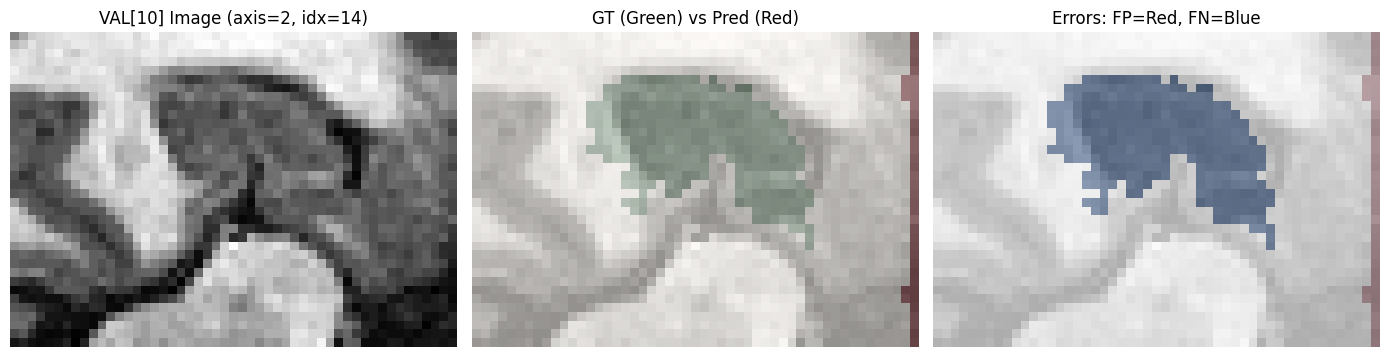

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()  # 이미 로드되어 있다고 가정
if hasattr(model, "do_ds"):
    model.do_ds = False

case_idx = 10  # 보고 싶은 val index

img_nii = nib.load(val_imgs[case_idx])
lab_nii = nib.load(val_labs[case_idx])

img = np.squeeze(img_nii.get_fdata()).astype(np.float32)
gt  = np.squeeze(lab_nii.get_fdata()).astype(np.int16)

img_norm = zscore_nonzero_np(img)

pred, prob = sliding_window_predict_mc_ds(
    model,
    img_norm,
    patch_size=(96,96,96),
    overlap=0.5,
    device=device
)

# GT가 0/1/2면 그대로 비교 가능, binary면 (gt>0)으로 통일하고 싶으면 아래 한 줄:
# gt = (gt > 0).astype(np.uint8)

visualize_case(img, gt, pred, axis=2, slice_idx=None, title_prefix=f"VAL[{case_idx}] ")